# Aesop AbstractGraph embedding and clustering

This notebook walks through the experiment in visible stages: loading the tales, building or reusing semantic graphs, converting those graphs to `AbstractGraph` objects, pooling graph features, building the text baseline, and clustering. The conversion cell prints the input/output graph types and sizes so the representation can be inspected before vectorization.

The Project Gutenberg edition is titled *Three Hundred Aesop's Fables* and contains 313 indexed tales. `SMOKE_TEST` and `SMOKE_LIMIT` control the sample size. Graph extraction and text embeddings use hosted APIs and may incur charges. Install with `pip install -e '.[dev,abstractgraph]'`. Generated data is stored under `data/processed/aesop_abstractgraph/`.


In [1]:
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys
from collections import Counter
import hashlib
import json
import pickle

import matplotlib.pyplot as plt
from abstractgraph import AbstractGraphTransformer
import numpy as np
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances

ROOT = Path.cwd()
if not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from semantic_graphicalizer import (
    DEFAULT_OPENAI_EMBEDDING_MODEL,
    DEFAULT_OPENAI_MODEL,
    OpenAIEmbeddingClient,
    SemanticGraphicalizer,
    load_aesop_fables,
)
from semantic_graphicalizer.model import as_embedding_client
from experiments.aesop_graph_embeddings_clustering import (
    _cluster_representations,
    _corpus_metadata,
    _load_or_build_text_vectors,
)

SMOKE_TEST = True
SMOKE_LIMIT = 32
EMBED_NODES = True
EMBEDDING_MODEL = DEFAULT_OPENAI_EMBEDDING_MODEL
RANDOM_SEED = 17
NBITS = 10
MAX_CLUSTER_SIZE = 10

cache_dir = ROOT / "data" / "processed" / "aesop_abstractgraph"
cache_dir.mkdir(parents=True, exist_ok=True)
stories = load_aesop_fables(
    limit=SMOKE_LIMIT if SMOKE_TEST else None,
    cache_dir=ROOT / "data" / "raw",
)
metadata, source_hashes, corpus_hash = _corpus_metadata(stories)
n_tales = len(stories)
print(f"Loaded {n_tales} tales; corpus SHA256: {corpus_hash}")


Loaded 32 tales; corpus SHA256: db047414f733d50588151ce4be5835555f6f16351fa03658445825c7d20f7120


## 1. Build or load the canonical semantic graphs

Each cached object here should be a NetworkX `MultiDiGraph`. On a cache miss, `SemanticGraphicalizer.transform([story])[0]` runs the extraction pipeline for that story and returns the canonical graph. The configuration hash keeps caches separate when the ontology or prompts change.


In [3]:
config_paths = {
    "ontology": ROOT / "configs" / "ontologies" / "aesop.yaml",
    "prompts": ROOT / "configs" / "prompts" / "aesop.yaml",
}
config_hashes = {
    name: hashlib.sha256(path.read_bytes()).hexdigest()
    for name, path in config_paths.items()
}
graph_config_hash = hashlib.sha256(json.dumps({
    "extraction_model": DEFAULT_OPENAI_MODEL,
    "config_sha256": config_hashes,
}, sort_keys=True).encode("utf-8")).hexdigest()

graphicalizer = SemanticGraphicalizer(
    ontology=config_paths["ontology"],
    prompts=config_paths["prompts"],
    embedding_model=EMBEDDING_MODEL,
)

graphs = []
for index, (story, row) in enumerate(zip(stories, metadata), start=1):
    checkpoint = cache_dir / f"{row['tale_id']}-{graph_config_hash[:8]}.graph.pkl"
    if checkpoint.exists():
        with checkpoint.open("rb") as handle:
            graph = pickle.load(handle)
        source = "cache"
    else:
        graph = graphicalizer.transform([story])[0]
        with checkpoint.open("wb") as handle:
            pickle.dump(graph, handle)
        source = "extracted"
    graphs.append(graph)
    print(
        f"{index:>3}/{len(stories)} {row['title']}: {source}; "
        f"{type(graph).__name__}, directed={graph.is_directed()}, "
        f"multigraph={graph.is_multigraph()}, nodes={graph.number_of_nodes()}, "
        f"edges={graph.number_of_edges()}"
    )


  1/32 The Lion And The Mouse: cache; MultiDiGraph, directed=True, multigraph=True, nodes=18, edges=26
  2/32 The Wolf And The Lamb: cache; MultiDiGraph, directed=True, multigraph=True, nodes=34, edges=32
  3/32 The Ass And The Grasshopper: cache; MultiDiGraph, directed=True, multigraph=True, nodes=16, edges=14
  4/32 The Wolf and the Crane: cache; MultiDiGraph, directed=True, multigraph=True, nodes=18, edges=18
  5/32 The Father And His Sons: cache; MultiDiGraph, directed=True, multigraph=True, nodes=23, edges=26
  6/32 The Bat And The Weasels: cache; MultiDiGraph, directed=True, multigraph=True, nodes=29, edges=28
  7/32 The Cock and the Jewel: cache; MultiDiGraph, directed=True, multigraph=True, nodes=14, edges=10
  8/32 The Swallow and the Crow: cache; MultiDiGraph, directed=True, multigraph=True, nodes=13, edges=10
  9/32 The Kingdom of the Lion: cache; MultiDiGraph, directed=True, multigraph=True, nodes=18, edges=16
 10/32 The Traveler and His Dog: cache; MultiDiGraph, directed=T

## 2. Convert semantic graphs to `AbstractGraph` objects

The semantic graph is a directed multigraph because relation arguments can create parallel edges. `to_abstract_graphs` converts each one into an `AbstractGraph` with a simple directed base graph. With `parallel_edge_policy="combine"`, parallel semantic edges are represented together in the base edge's `semantic_edges` metadata. Node embeddings are optionally copied to the base nodes' numeric `attribute` vectors.

Each AbstractGraph also has an interpretation graph. The next cell prints both graph sizes and checks how many semantic edges were combined.


In [4]:
abstract_settings = {
    "embedding_key": "embedding",
    "interpretation_mode": "per_entity",
    "chunk_key": "chunk_id",
    "parallel_edge_policy": "first",
    "preserve_direction": False,
    "nbits": NBITS,
}

# This call may compute embeddings for semantic nodes first, then converts each
# MultiDiGraph to an AbstractGraph. The returned objects are already converted;
# they must not be passed back into a transformer that wraps raw NetworkX graphs.
abstract_graphs = graphicalizer.to_abstract_graphs(
    graphs,
    embed_nodes=EMBED_NODES,
    **abstract_settings,
)

conversion_rows = []
for row, semantic_graph, abstract_graph in zip(metadata, graphs, abstract_graphs):
    base = abstract_graph.base_graph
    combined_edge_count = sum(
        max(0, len(data.get("semantic_edges", [])) - 1)
        for _source, _target, data in base.edges(data=True)
    )
    embedded_nodes = sum("attribute" in data for _node, data in base.nodes(data=True))
    conversion_rows.append({
        "tale": row["title"],
        "input_type": type(semantic_graph).__name__,
        "input_nodes": semantic_graph.number_of_nodes(),
        "input_edges": semantic_graph.number_of_edges(),
        "base_type": type(base).__name__,
        "base_directed": base.is_directed(),
        "base_multigraph": base.is_multigraph(),
        "base_nodes": base.number_of_nodes(),
        "base_edges": base.number_of_edges(),
        "combined_parallel_edges": combined_edge_count,
        "interpretation_nodes": abstract_graph.interpretation_graph.number_of_nodes(),
        "nodes_with_numeric_attributes": embedded_nodes,
    })

try:
    import pandas as pd
    display(pd.DataFrame(conversion_rows))
except ImportError:
    display(conversion_rows)

# Show a small before/after sample. A combined base edge retains all of its
# source semantic edges (including their original role and direction).
sample_index = 0
semantic_sample = graphs[sample_index]
abstract_sample = abstract_graphs[sample_index]
print(f"\nConversion sample: {metadata[sample_index]['title']}")
print("Semantic nodes:")
for node_id, data in list(semantic_sample.nodes(data=True))[:5]:
    print(f"  {node_id!r}: type={data.get('type')!r}, relation={data.get('relation')!r}")
print("Abstract base nodes:")
for node_id, data in list(abstract_sample.base_graph.nodes(data=True))[:5]:
    attribute = data.get("attribute")
    attribute_shape = None if attribute is None else np.asarray(attribute).shape
    print(f"  {node_id!r}: label={data.get('label')!r}, attribute_shape={attribute_shape}")
print("Semantic edges:")
for source, target, key, data in list(semantic_sample.edges(keys=True, data=True))[:5]:
    print(f"  {source!r} -> {target!r} [{key!r}]: role={data.get('role')!r}")
print("Abstract base edges:")
for source, target, data in list(abstract_sample.base_graph.edges(data=True))[:5]:
    print(f"  {source!r} -> {target!r}: label={data.get('label')!r}; ")
    for semantic_edge in data.get("semantic_edges", []):
        print(f"      source={semantic_edge.get('source')!r}, target={semantic_edge.get('target')!r}, role={semantic_edge.get('role')!r}")


,tale,input_type,input_nodes,input_edges,base_type,base_directed,base_multigraph,base_nodes,base_edges,combined_parallel_edges,interpretation_nodes,nodes_with_numeric_attributes
0,The Lion And The Mouse,MultiDiGraph,18,26,Graph,False,False,18,26,0,18,18
1,The Wolf And The Lamb,MultiDiGraph,34,32,Graph,False,False,34,32,0,34,34
2,The Ass And The Grasshopper,MultiDiGraph,16,14,Graph,False,False,16,14,0,16,16
3,The Wolf and the Crane,MultiDiGraph,18,18,Graph,False,False,18,18,0,18,18
4,The Father And His Sons,MultiDiGraph,23,26,Graph,False,False,23,21,0,23,23
5,The Bat And The Weasels,MultiDiGraph,29,28,Graph,False,False,29,28,0,29,29
6,The Cock and the Jewel,MultiDiGraph,14,10,Graph,False,False,14,10,0,14,14
7,The Swallow and the Crow,MultiDiGraph,13,10,Graph,False,False,13,10,0,13,13
8,The Kingdom of the Lion,MultiDiGraph,18,16,Graph,False,False,18,16,0,18,18
9,The Traveler and His Dog,MultiDiGraph,20,20,Graph,False,False,20,20,0,20,20



Conversion sample: The Lion And The Mouse
Semantic nodes:
  'animal::lion': type='Animal', relation=None
  'animal::mouse': type='Animal', relation=None
  'trait::mercy': type='Trait', relation=None
  'object::strong_ropes': type='Object', relation=None
  'moral::kindness_repaid': type='Moral', relation=None
Abstract base nodes:
  'animal::lion': label='', attribute_shape=(1536,)
  'animal::mouse': label='', attribute_shape=(1536,)
  'trait::mercy': label='', attribute_shape=(1536,)
  'object::strong_ropes': label='', attribute_shape=(1536,)
  'moral::kindness_repaid': label='', attribute_shape=(1536,)
Semantic edges:
  'document-fbdceb1ca5cd:chunk-0:relation:r1' -> 'animal::mouse' ['argument:document-fbdceb1ca5cd:chunk-0:relation:r1:0']: role='performer'
  'document-fbdceb1ca5cd:chunk-0:relation:r1' -> 'document-fbdceb1ca5cd:chunk-0:relation:r1' ['argument:document-fbdceb1ca5cd:chunk-0:relation:r1:1']: role='action'
  'document-fbdceb1ca5cd:chunk-0:relation:r2' -> 'animal::lion' ['ar

### Inspect one conversion directly

This standalone call makes the `SemanticGraphicalizer.to_abstract_graph` conversion explicit for the first tale. The batch conversion above supplies the collection used by the experiment; this cell exposes the single-graph result and its graph sizes.

In [5]:
abstract_graph = graphicalizer.to_abstract_graph(
    graphs[0],
    interpretation_mode="per_entity",
    preserve_direction=False,
    embed_nodes=True,
    embedding_dim=64,
    parallel_edge_policy="first",
)

print(f"Example tale: {metadata[0]['title']}")
print("Result type:", type(abstract_graph).__name__)
print("Base graph:", type(abstract_graph.base_graph).__name__)
print(
    "Base graph shape:",
    f"{abstract_graph.base_graph.number_of_nodes()} nodes,",
    f"{abstract_graph.base_graph.number_of_edges()} edges,",
    f"directed={abstract_graph.base_graph.is_directed()}",
)
print(
    "Interpretation graph:",
    f"{abstract_graph.interpretation_graph.number_of_nodes()} nodes,",
    f"{abstract_graph.interpretation_graph.number_of_edges()} edges",
)


Example tale: The Lion And The Mouse
Result type: AbstractGraph
Base graph: Graph
Base graph shape: 18 nodes, 26 edges, directed=False
Interpretation graph: 18 nodes, 0 edges


### Display the converted graph after edge intersection

Convert the first tale, apply `intersection_edges` from `abstractgraph.operators`, then render the resulting AbstractGraph with labels and an undirected layout.

In [12]:
graphicalizer.display(
    graphs[0],
    mode="dynamic",
    layout="force",
    show_derived_links=True,
    show_source=True,
    max_width=34,
    width=1200,
    height=760,
    charge_strength=-10,
    link_distance=150,
    component_spacing=100,
    component_strength=0.3,
    parallel_edge_spacing=320
)

<Axes: >

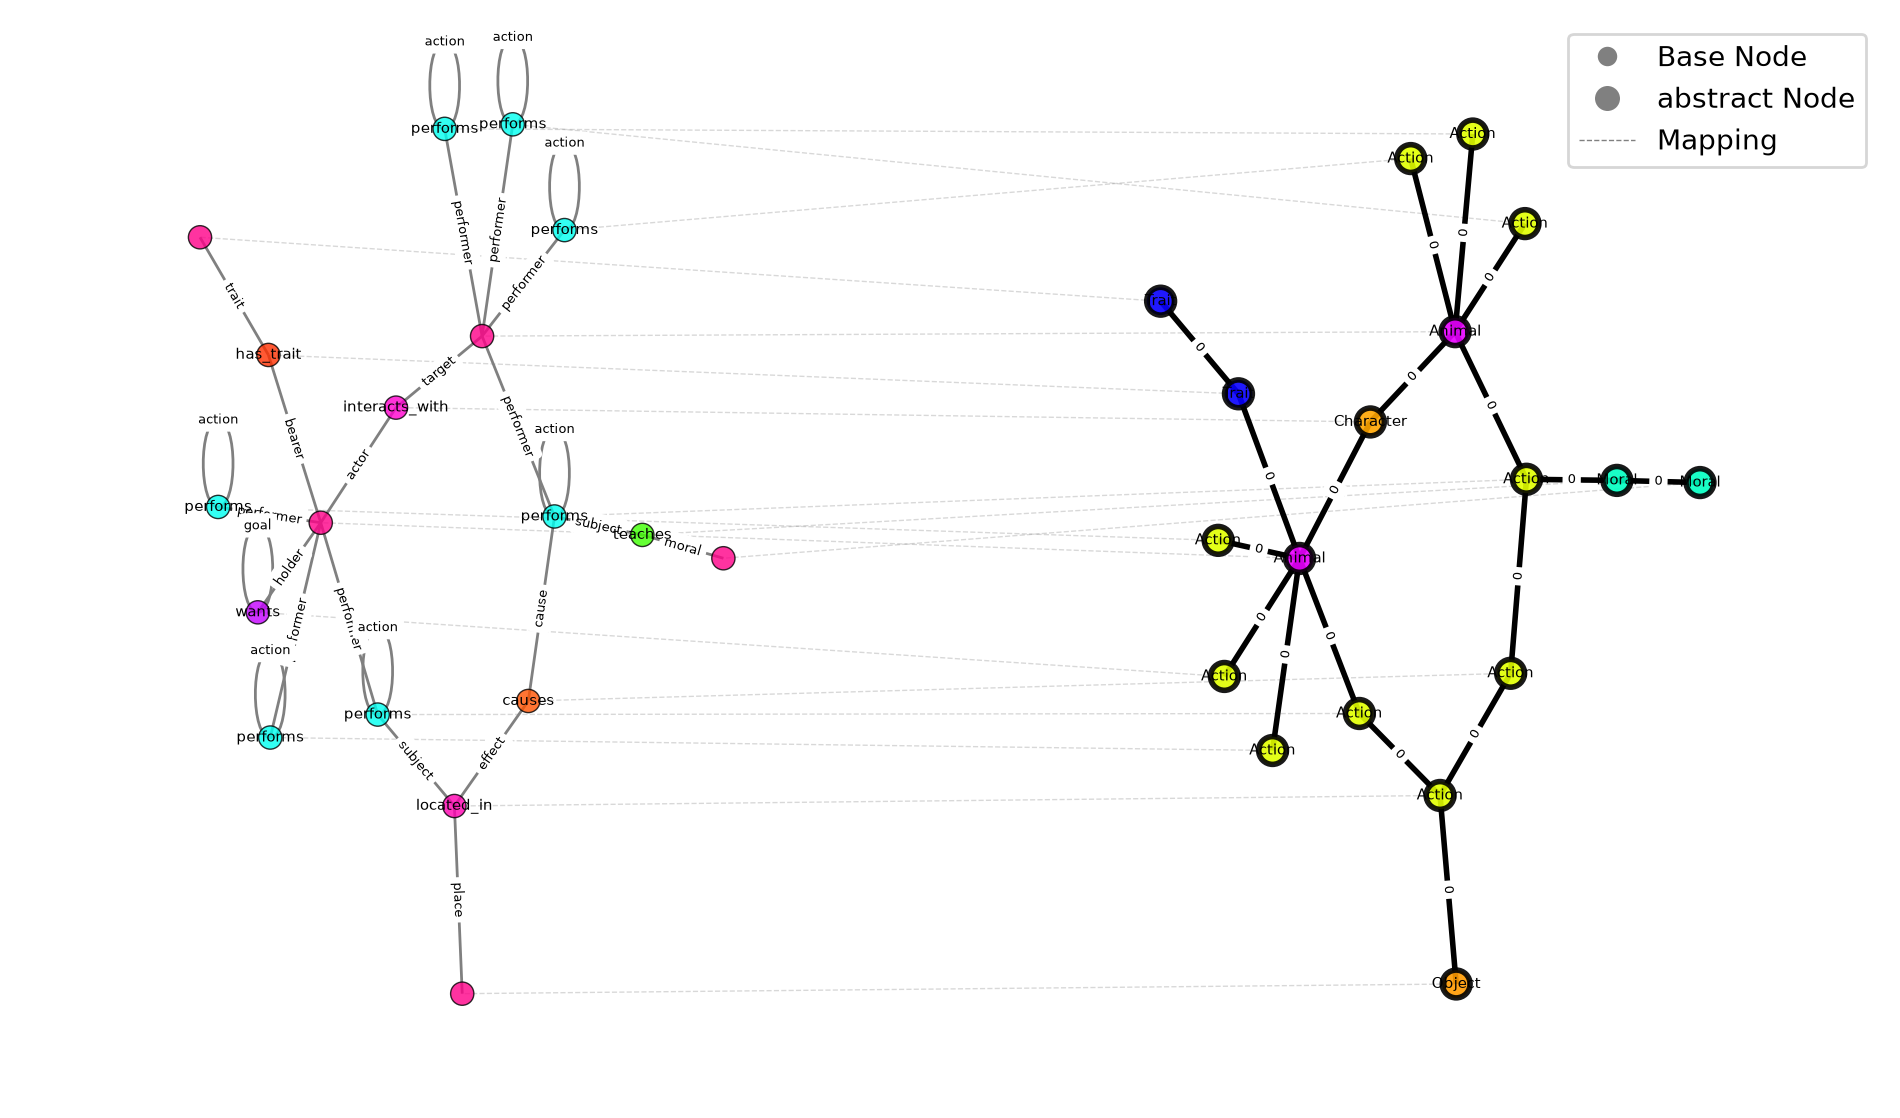

In [ ]:
from abstractgraph import display as display_abstract_graph
from abstractgraph.operators import *

abstract_graph = graphicalizer.to_abstract_graph(
    graphs[0],
    interpretation_mode="per_entity",
    preserve_direction=False,
    embed_nodes=True,
    parallel_edge_policy="first",
)

abstract_graph = intersection_edges(abstract_graph, accept_connection_by_edge=True)
display_abstract_graph(
    abstract_graph,
    size=(12, 7),
    show_legend=True,
    node_labels=True,
    node_label_attr="label",
    node_label_font_size=5.5,
    edge_labels=True,
    edge_label_font_size=4.5,
    undirected_layout=True,
)


## 3. Vectorize each tale with `AbstractGraphTransformer`

The transformer accepts the pre-built `AbstractGraph` objects directly. It copies each object, preserving its base graph, interpretation mappings, and attribute function, then applies the library's `vectorize()` function and sums the node rows into one sparse vector per tale.

Before vectorization, inspect `to_array()` on a converted object to see its node-level feature matrix. `AbstractGraphTransformer` also sets feature columns 0 and 1 to bias and base-node degree before pooling.


In [7]:
graph_transformer = AbstractGraphTransformer(
    nbits=NBITS,
    decomposition_function=None,
    return_dense=False,
    n_jobs=1,
)
graph_matrix = graph_transformer.fit_transform(abstract_graphs)
print(f"Graph-level matrix: {graph_matrix.shape}; format={graph_matrix.format}; nnz={graph_matrix.nnz}")

# Save node embeddings added during AbstractGraph conversion to the graph cache.
for graph, row in zip(graphs, metadata):
    checkpoint = cache_dir / f"{row['tale_id']}-{graph_config_hash[:8]}.graph.pkl"
    with checkpoint.open("wb") as handle:
        pickle.dump(graph, handle)


Graph-level matrix: (32, 1572864); format=csr; nnz=293438


## 4. Build the direct-text baseline and cluster both representations

This last stage uses the same cached text-embedding and clustering routines as the experiment module. Graph conversion and pooling above are now fully visible in this notebook.


In [8]:
raw_embedder = graphicalizer.embedder or OpenAIEmbeddingClient(model=EMBEDDING_MODEL)
embedding_client = as_embedding_client(raw_embedder)
text_matrix = _load_or_build_text_vectors(
    stories,
    source_hashes,
    embedding_client,
    cache_dir / "direct_text_vectors.pkl",
    EMBEDDING_MODEL,
)

clustering = _cluster_representations(
    graph_matrix, text_matrix, RANDOM_SEED, max_cluster_size=MAX_CLUSTER_SIZE
)
graph_features = clustering["graph_features"]
text_features = clustering["text_features"]
cluster_results = clustering["cluster_results"]
metric_rows = clustering["metric_rows"]
agreement_rows = clustering["agreement_rows"]
max_cluster_size = clustering["max_cluster_size"]
print(f"Tales: {n_tales} | graph vectors: {graph_matrix.shape} | text vectors: {text_matrix.shape}")
print(f"Graph reduction components: {clustering['svd_components']}")
print(f"Maximum tales per cluster: {max_cluster_size}")


Tales: 32 | graph vectors: (32, 1572864) | text vectors: (32, 1536)
Graph reduction components: 31
Maximum tales per cluster: 10


## What the experiment computes

Each tale gets two representations. In the graph path, the pipeline segments the story, summarizes and normalizes each chunk, decomposes it into assertions, extracts entities and relations, then tries to add higher-order relations in the resolve stage. It optionally embeds graph nodes, converts the semantic graph to an `AbstractGraph`, and sums the node feature rows into one sparse vector per tale. Because this is a sum, graph size and repeated features can affect vector magnitude. The text baseline splits each tale into chunks of up to 6,000 characters, embeds each chunk, and averages the chunk vectors.

Extraction and resolution use the same reference validation and retry mechanism. The model gets feedback when an argument points to an unknown ID. If invalid references remain after retries, those relations and any relations depending on them are omitted. If a stage keeps returning structurally invalid output or fails, that extraction chunk or optional resolve stage is skipped so processing can continue.

Before clustering, the sparse graph vectors are scaled without centering and reduced with TruncatedSVD to at most 50 components. The text vectors are standardized in their original embedding space. Ward hierarchical clustering is run on both representations. Oversized tree branches are split until each cluster has at most `MAX_CLUSTER_SIZE` tales (default 5).


## Compare clusterings

Metric scores are inspection aids, not proof of semantic quality. Compare representative tales and boundary cases before drawing conclusions.


In [9]:
try:
    import pandas as pd
    metrics = pd.DataFrame(metric_rows).sort_values(
        ["representation", "silhouette"], ascending=[True, False]
    )
    display(metrics)
except ImportError:
    display(metric_rows)

for row in agreement_rows:
    print(f"max size={row['max_cluster_size']}: ARI={row['ari']:.3f}, NMI={row['nmi']:.3f}")


,representation,algorithm,max_cluster_size,cluster_count,largest_cluster,silhouette,calinski_harabasz,davies_bouldin
0,AbstractGraph,hierarchical_ward,10,8,10,0.001857,3.341236,1.667441
1,Direct text,hierarchical_ward,10,4,10,0.013625,1.832986,2.879950


max size=10: ARI=0.101, NMI=0.324


## How to read the scores

- **Silhouette** ranges from −1 to 1; higher means points are closer to their own cluster than to neighboring clusters. Values near 0 suggest overlap, and negative values can indicate poor assignments.
- **Calinski–Harabasz** compares between-cluster spread with within-cluster spread; higher is generally better.
- **Davies–Bouldin** measures how similar clusters are to their nearest neighboring cluster; lower is generally better.

Use these scores to compare choices within the same representation. Graph and text vectors live in different feature spaces, so their score magnitudes are not directly comparable. The ARI and NMI line compares the *assignments* from graph and text hierarchical clustering at the same maximum cluster size: ARI is 1 for identical partitions and about 0 for chance-level agreement; NMI ranges from 0 (no shared information) to 1 (identical partitions). Agreement does not establish that either clustering is correct.


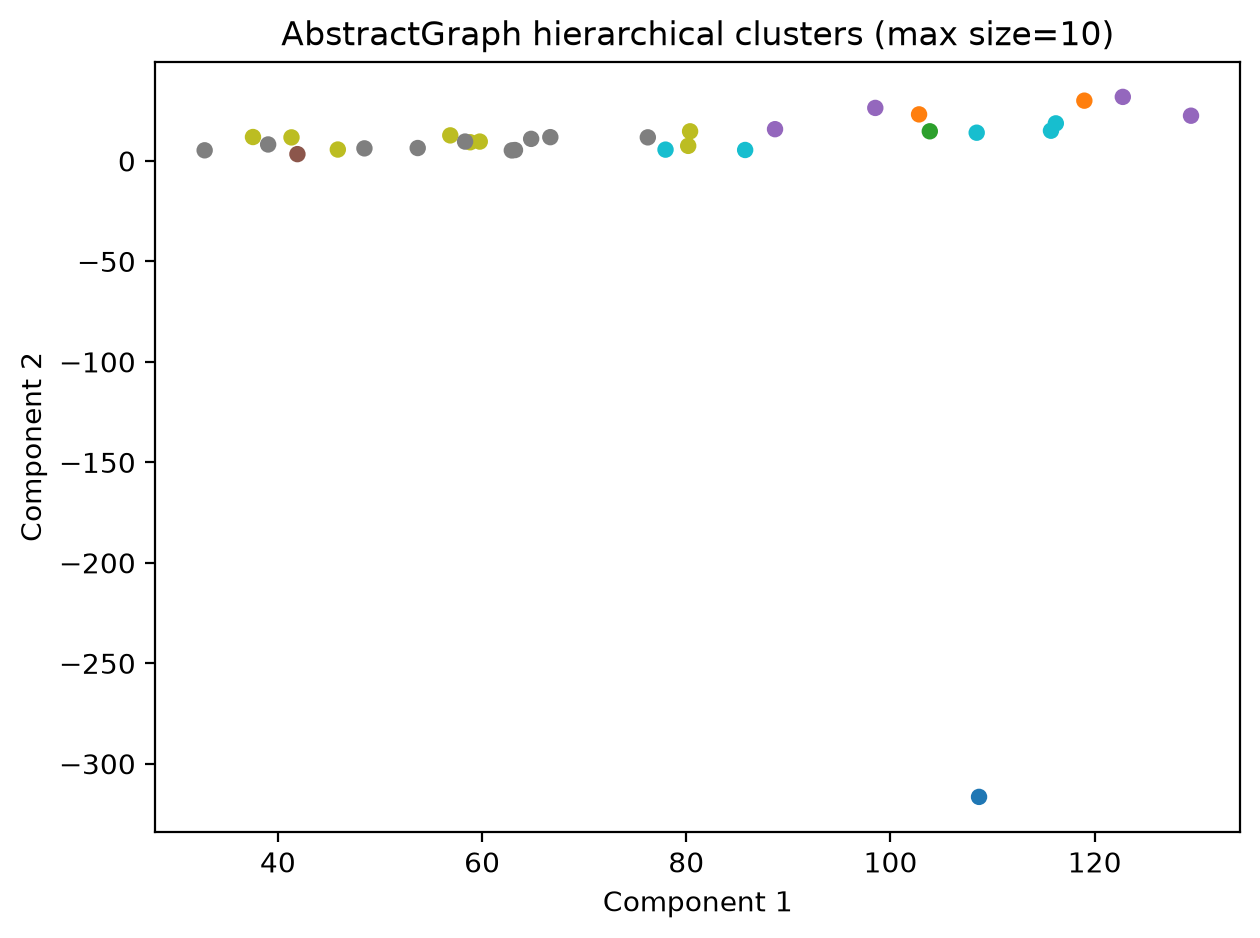

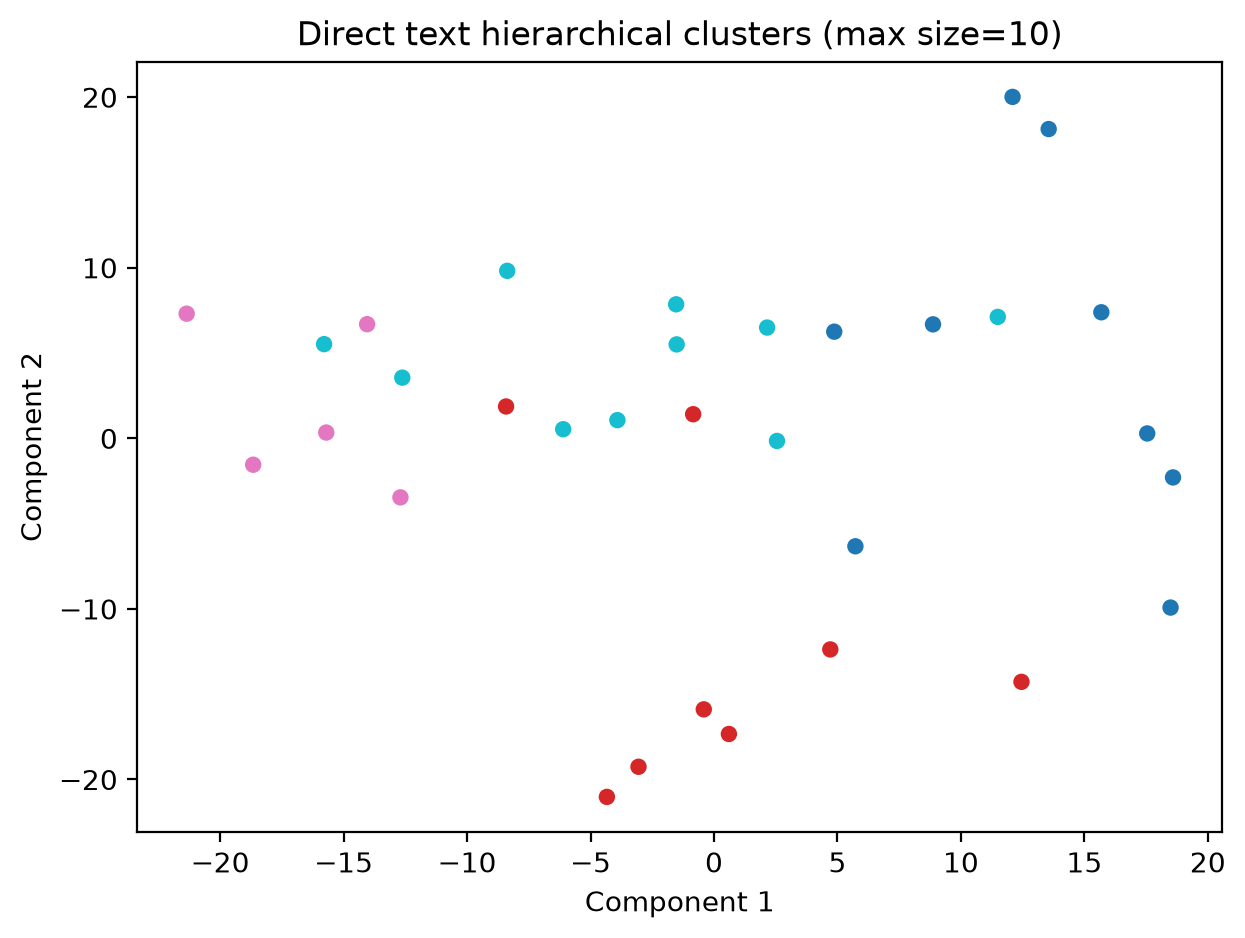

### Cluster 0 (1 tales) — representative: The Lion And The Mouse


The Lion And The Mouse (aesop-0000-fbdceb1ca5cd)
The Lion And The Mouse


A LION was awakened from sleep by a Mouse running over his face. Rising
up angrily, he caught him and was about to kill him, when the Mouse
piteously entreated, saying: “If you would only spare my life, I would
be sure to repay your kindness.” The Lion laughed and let him go. It
happened shortly after this that the Lion was caught by some hunters,
who bound him by strong ropes to the ground. The Mouse, recognizing his
roar, came and gnawed the rope with his teeth, and set him free,
exclaiming:

“You ridiculed the idea of my ever being able to help you, not
expecting to receive from me any repayment of your favour; now you know
that it is possible for even a Mouse to confer benefits on a Lion.”

Representative graph summary:
Entity types: [('Action', 10), ('Animal', 2), ('Trait', 2), ('Moral', 2), ('Object', 1), ('Character', 1)]
Relations: [('performs', 7), ('wants', 1), ('has_trait', 1), ('located_in', 1), ('in

### Cluster 1 (2 tales) — representative: The Hare and the Tortoise


The Hare and the Tortoise (aesop-0011-63440dd8bb59)
The Hare and the Tortoise


A HARE one day ridiculed the short feet and slow pace of the Tortoise,
who replied, laughing: “Though you be swift as the wind, I will beat
you in a race.” The Hare, believing her assertion to be simply
impossible, assented to the proposal; and they agreed that the Fox
should choose the course and fix the goal. On the day appointed for the
race the two started together. The Tortoise never for a moment stopped,
but went on with a slow but steady pace straight to the end of the
course. The Hare, lying down by the wayside, fell fast asleep. At last
waking up, and moving as fast as he could, he saw the Tortoise had
reached the goal, and was comfortably dozing after her fatigue.

Slow but steady wins the race.

The Herdsman and the Lost Bull (aesop-0018-edfea1cb91c6)
The Herdsman and the Lost Bull


A HERDSMAN tending his flock in a forest lost a Bull-calf from the
fold. After a long and fruitless search, he ma

### Cluster 2 (1 tales) — representative: The Raven and the Swan

...


The Swallow and the Crow (aesop-0007-df933b19eb43)
The Swallow and the Crow


THE SWALLOW and the Crow had a contention about their plumage. The Crow
put an end to the dispute by saying, “Your feathers are all very well
in the spring, but mine protect me against the winter.”

Fair weather friends are not worth much.

The Traveler and His Dog (aesop-0009-03b0e50fd942)
The Traveler and His Dog


A TRAVELER about to set out on a journey saw his Dog stand at the door
stretching himself. He asked him sharply: “Why do you stand there
gaping? Everything is ready but you, so come with me instantly.” The
Dog, wagging his tail, replied: “O, master! I am quite ready; it is you
for whom I am waiting.”

The loiterer often blames delay on his more active friend.

The Ants and the Grasshopper (aesop-0010-84bfefc2ce08)
The Ants and the Grasshopper


THE ANTS were spending a fine winter’s day drying grain collected in
the summertime. A Grasshopper, perishing with famine, passed by and
earnestly begged

### Cluster 6 (8 tales) — representative: The Cock and the Jewel


The Ass And The Grasshopper (aesop-0002-932912a3e124)
The Ass And The Grasshopper


AN ASS having heard some Grasshoppers chirping, was highly enchanted;
and, desiring to possess the same charms of melody, demanded what sort
of food they lived on to give them such beautiful voices. They replied,
“The dew.” The Ass resolved that he would live only upon dew, and in a
short time died of hunger.

The Cock and the Jewel (aesop-0006-09249401f17d)
The Cock and the Jewel


A COCK, scratching for food for himself and his hens, found a precious
stone and exclaimed: “If your owner had found thee, and not I, he would
have taken thee up, and have set thee in thy first estate; but I have
found thee for no purpose. I would rather have one barleycorn than all
the jewels in the world.”

The Kingdom of the Lion (aesop-0008-4e5f8a376f3e)
The Kingdom of the Lion


THE BEASTS of the field and forest had a Lion as their king. He was
neither wrathful, cruel, nor tyrannical, but just and gentle as a king
cou

### Cluster 7 (5 tales) — representative: The Wolf and the Crane


The Wolf and the Crane (aesop-0003-192d80ea9aa8)
The Wolf and the Crane


A WOLF who had a bone stuck in his throat hired a Crane, for a large
sum, to put her head into his mouth and draw out the bone. When the
Crane had extracted the bone and demanded the promised payment, the
Wolf, grinning and grinding his teeth, exclaimed: “Why, you have surely
already had a sufficient recompense, in having been permitted to draw
out your head in safety from the mouth and jaws of a wolf.”

In serving the wicked, expect no reward, and be thankful if you escape
injury for your pains.

The Father And His Sons (aesop-0004-c731227fcc91)
The Father And His Sons


A FATHER had a family of sons who were perpetually quarreling among
themselves. When he failed to heal their disputes by his exhortations,
he determined to give them a practical illustration of the evils of
disunion; and for this purpose he one day told them to bring him a
bundle of sticks. When they had done so, he placed the faggot into the
h

In [10]:
from textwrap import wrap

def print_wrapped_story(text, width=80):
    for paragraph in text.splitlines():
        wrapped = wrap(paragraph, width=width)
        print("\n".join(wrapped))

for representation, features, reducer in (
    ("AbstractGraph", graph_features, None),
    ("Direct text", text_features, PCA(n_components=2, random_state=RANDOM_SEED)),
):
    coordinates = reducer.fit_transform(features) if reducer is not None else features[:, :2]
    labels = cluster_results[(representation, "hierarchical_ward", max_cluster_size)]
    plt.figure(figsize=(7, 5))
    plt.scatter(coordinates[:, 0], coordinates[:, 1], c=labels, cmap="tab10", s=24)
    plt.title(f"{representation} hierarchical clusters (max size={max_cluster_size})")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

labels = cluster_results[("AbstractGraph", "hierarchical_ward", max_cluster_size)]
for label in sorted(set(labels)):
    members = np.flatnonzero(labels == label)
    distances = pairwise_distances(graph_features[members], metric="euclidean")
    medoid_index = members[int(np.argmin(distances.mean(axis=1)))]
    display(Markdown(
        f"### Cluster {label} ({len(members)} tales) — "
        f"representative: {metadata[medoid_index]['title']}"
    ))
    for member_index in members:
        row = metadata[member_index]
        print(f"\n{row['title']} ({row['tale_id']})")
        print_wrapped_story(stories[member_index], width=80)
    graph = graphs[medoid_index]
    entity_types = Counter(data.get("type") for _node, data in graph.nodes(data=True))
    relation_names = Counter(
        data.get("relation") for _node, data in graph.nodes(data=True)
        if data.get("relation")
    )
    argument_roles = Counter(
        data.get("role") for _source, _target, data in graph.edges(data=True)
    )
    print("\nRepresentative graph summary:")
    print("Entity types:", entity_types.most_common(6))
    print("Relations:", relation_names.most_common(6))
    print("Argument roles:", argument_roles.most_common(6))


## How to read the plots and tale examples

Colors show the Ward hierarchical cluster assignments with the configured maximum cluster size. Graph coordinates are the first two SVD features; text coordinates come from PCA. The axes have no direct semantic meaning, and positions should only be interpreted within each plot.

For each graph cluster, the notebook prints every member tale. The listed representative is the **medoid**: the tale with the lowest average Euclidean distance to the other members in the reduced graph feature space. Its entity-type, relation, and argument-role counts give a quick structural profile of that representative; they are not cluster-wide totals.

These are exploratory, unsupervised results. Extraction or resolution fallbacks can leave some graphs with fewer relations; embedding choices, corpus size, and feature scaling can also change the clusters. Read the tales and inspect borderline cases before treating a pattern as meaningful.


Inspect excerpts, recurring entity types, relations, argument roles, nearest tales, and boundary cases. Cached graph artifacts are stored under `data/processed/aesop_abstractgraph/` and are keyed by tale content and extraction configuration.
